In [1]:
#Import the required libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Load the dataset
df = pd.read_csv(r"agricultural_yield.csv")
df.head()

,Soil_Quality,Seed_Variety,Fertilizer_Amount_kg_per_hectare,Sunny_Days,Rainfall_mm,Irrigation_Schedule,Yield_kg_per_hectare
0,93.304721,0,132.522218,96.670922,602.386237,3,278.986563
1,83.674653,1,57.283997,99.007556,466.518251,8,836.434840
2,65.963033,1,227.895479,104.844272,510.320495,4,785.881787
3,78.692834,1,176.314126,90.136191,354.350914,5,807.884526
4,72.415684,1,160.070418,101.221668,443.993788,10,1064.542374


In [14]:
df.shape

(4000, 7)

In [3]:
df.columns

Index(['Soil_Quality', 'Seed_Variety', 'Fertilizer_Amount_kg_per_hectare',
       'Sunny_Days', 'Rainfall_mm', 'Irrigation_Schedule',
       'Yield_kg_per_hectare'],
      dtype='object')

In [6]:
#Features and target feature
X = df[['Soil_Quality', 'Seed_Variety', 'Fertilizer_Amount_kg_per_hectare',
       'Sunny_Days', 'Rainfall_mm', 'Irrigation_Schedule']]
y = df['Yield_kg_per_hectare']

In [7]:
#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
#Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# Predicting 
y_pred = model.predict(X_test)

In [10]:
y_pred

array([ 439.1975805 ,  666.33209798, 1076.94191683,  664.21281882,
        808.02298804,  996.98407306,  313.77572225,  599.49240463,
        459.04167512,  808.6592018 ,  604.04847914,  687.23421527,
        634.73571196,  749.03488482,  853.92218459,  687.93014874,
        963.13199292,  468.23920474,  576.54686601,  365.26800046,
        801.43980025,  803.11719055,  363.29593982,  826.97963685,
       1014.00877906,  593.75133133,  671.48334758,  972.21146781,
        642.99322648,  641.35352632,  696.34389969,  812.99156483,
        834.21274195,  795.2222746 ,  464.01757953,  719.08330073,
        727.71450606, 1016.34576828,  185.19401708,  666.31133171,
        928.96688352,  892.94425603,  789.43259421,  756.64848685,
        600.40814516,  836.04318603,  611.14617154,  570.60052803,
        602.09300718,  797.12370327,  621.0098251 ,  784.02214988,
        848.83223874,  768.07645087,  436.76237678,  720.14334399,
        648.45392607,  773.4420461 ,  684.0855623 ,  699.60892

In [11]:
# Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 2337.6382390455638
R-squared: 0.9405847109249214


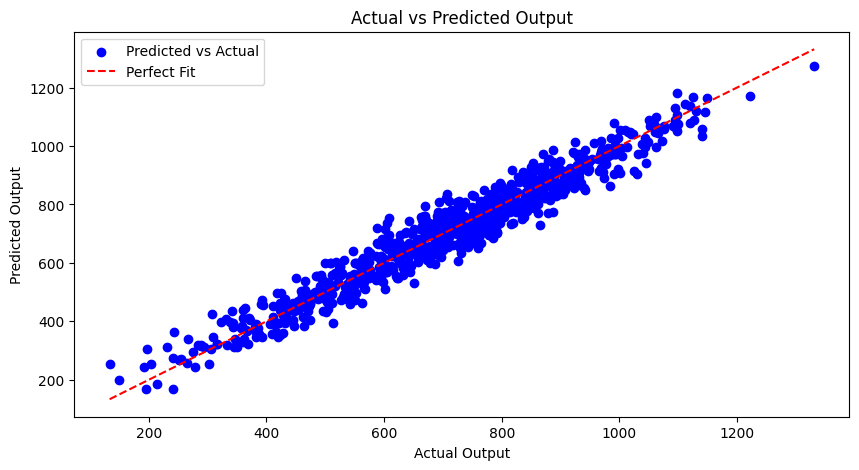

In [12]:
import matplotlib.pyplot as plt

# Scatter plot to compare actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
# Diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel("Actual Output")
plt.ylabel("Predicted Output")
plt.title("Actual vs Predicted Output")
plt.legend()
plt.show()

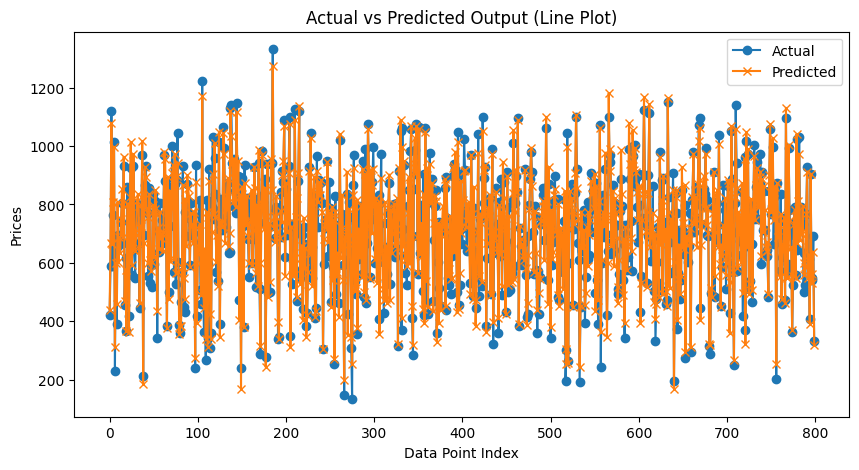

In [13]:
# Line plot to show predictions and actual values
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test, label="Actual", marker='o')
plt.plot(range(len(y_test)), y_pred, label="Predicted", marker='x')
plt.xlabel("Data Point Index")
plt.ylabel("Prices")
plt.title("Actual vs Predicted Output (Line Plot)")
plt.legend()
plt.show()

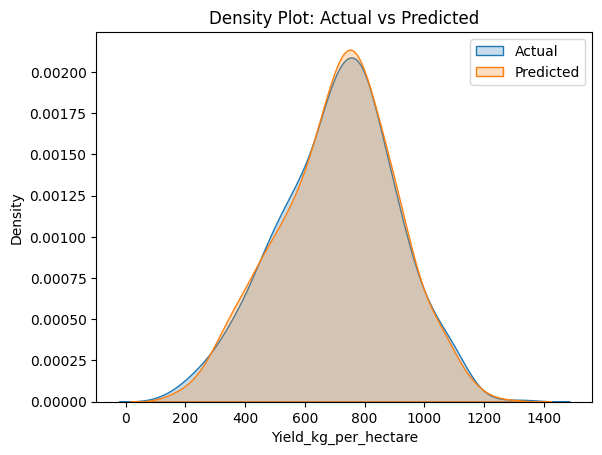

In [15]:
import seaborn as sns

sns.kdeplot(y_test, label="Actual", fill=True)
sns.kdeplot(y_pred, label="Predicted", fill=True)

plt.title("Density Plot: Actual vs Predicted")
plt.legend()
plt.show()
